# **Training**

In [10]:
import pandas as pd

df = pd.read_csv('/kaggle/working/features_handcraft_pca.csv')

In [11]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Columns: 513 entries, 0 to label
dtypes: float64(513)
memory usage: 12.5 MB


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,label
0,-86.807830,-24.360528,5.495313,-46.491649,-49.792504,-57.115706,24.693054,-21.063006,-24.267926,3.915368,...,2.529416,3.448741,-3.836246,-5.028321,0.154646,5.623188,-4.891234,2.370900,0.847790,0.0
1,-243.866849,15.709990,35.719134,-16.492731,4.545443,5.165321,6.769105,11.430433,2.914487,-11.905998,...,-4.072603,-4.586755,-2.431177,-7.203362,-1.361131,1.184175,-4.745517,-9.938579,1.819129,0.0
2,-26.173881,47.317555,-0.285895,-12.909010,22.087514,22.981419,48.636205,-21.991330,-7.914629,-3.568062,...,-1.563801,-6.410123,-5.789411,1.349778,-1.317770,6.442150,3.652518,3.590846,5.753142,0.0
3,-145.741606,104.450955,10.984045,-28.758778,-13.554881,-9.263339,3.214194,1.766616,9.460335,17.917835,...,4.029490,2.827033,-3.015787,3.550703,8.528090,3.673740,-8.283408,-5.435517,4.341665,1.0
4,-201.072409,-24.233997,-28.298413,21.504664,10.355752,-6.370992,-7.466882,27.408755,12.394824,-13.227208,...,-0.613423,0.197246,-0.249241,-0.283457,-0.935764,0.115995,0.387296,0.160842,-0.514637,1.0


In [12]:
X = df.drop('label', axis=1)
y = df['label']

In [13]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [14]:

Xh_train, Xh_test, yh_train, yh_test = train_test_split(X, y, test_size=0.3, random_state=42)

## **Logistic**

              precision    recall  f1-score   support

         0.0       0.69      0.78      0.73       432
         1.0       0.80      0.72      0.76       526

    accuracy                           0.75       958
   macro avg       0.75      0.75      0.74       958
weighted avg       0.75      0.75      0.75       958



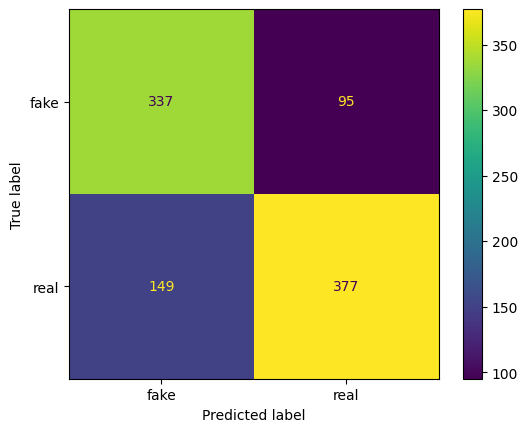

In [20]:
lgt_model = LogisticRegression(solver='newton-cholesky')
lgt_model.fit(Xh_train,yh_train)
y_pred = lgt_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test,y_pred),display_labels=['fake','real']).plot()

### **cross-validation-lgt**

In [21]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

lgt_model = LogisticRegression(solver='newton-cholesky')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lgt_model, Xh_train, yh_train, cv=kf, scoring='accuracy')

print(f"Accuracy từng fold: {scores}")
print(f"Mean accuracy: {np.mean(scores):.4f}")

Accuracy từng fold: [0.71588367 0.74496644 0.70917226 0.74496644 0.73991031]
Mean accuracy: 0.7310


## **SVM**

              precision    recall  f1-score   support

         0.0       0.80      0.88      0.83       432
         1.0       0.89      0.82      0.85       526

    accuracy                           0.84       958
   macro avg       0.84      0.85      0.84       958
weighted avg       0.85      0.84      0.84       958



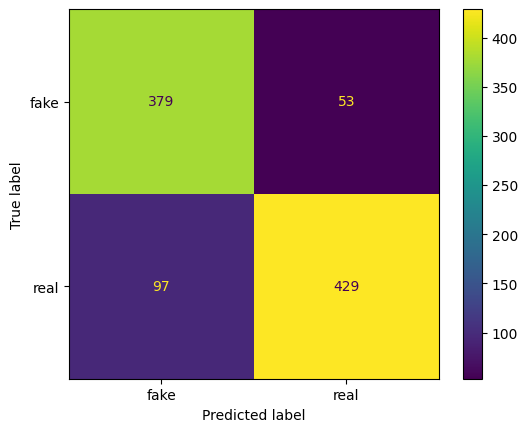

In [22]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1, gamma='scale')  

svm_model.fit(Xh_train, yh_train)

y_pred = svm_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()

### **save-model-svm**

In [ ]:
mport joblib

joblib.dump(svm_model,'svm_model.pkl')

## **grid-search**

Fitting 10 folds for each of 5 candidates, totalling 50 fits
best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

         0.0       0.79      0.86      0.82       432
         1.0       0.88      0.81      0.84       526

    accuracy                           0.83       958
   macro avg       0.83      0.84      0.83       958
weighted avg       0.84      0.83      0.83       958



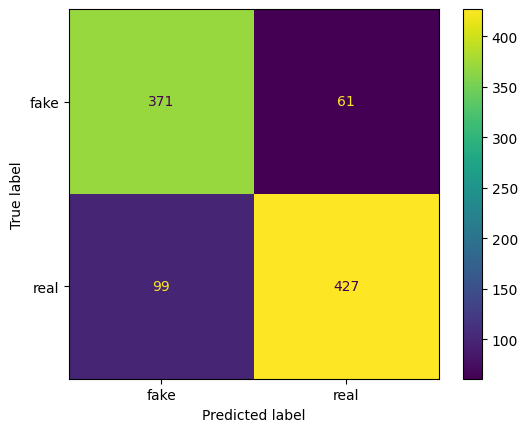

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   
    'gamma': ['scale'],           
    'kernel': ['rbf']              
}

#GridSearchCV
grid = GridSearchCV(
    SVC(), 
    param_grid, 
    cv=10,             
    verbose=2,        
    n_jobs=-1         
)

grid.fit(Xh_train, yh_train)

print("best parameters:", grid.best_params_)

best_svm = grid.best_estimator_
y_pred = best_svm.predict(Xh_test)

print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()

## **SVM Tự cài đặt**

              precision    recall  f1-score   support

        fake       0.45      0.38      0.41       432
        real       0.55      0.61      0.57       526

    accuracy                           0.51       958
   macro avg       0.50      0.50      0.49       958
weighted avg       0.50      0.51      0.50       958



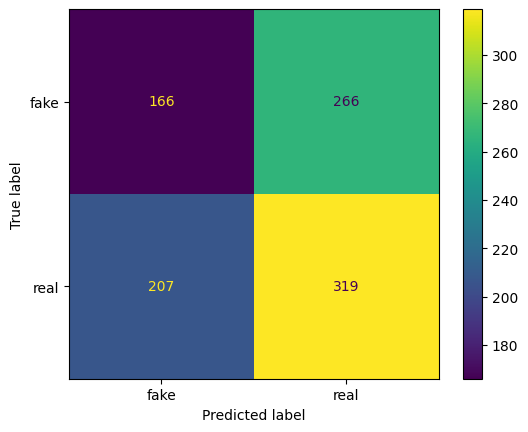

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class CustomSVM:
    def __init__(self, C=1.0, gamma='scale', learning_rate=0.01, max_iterations=1000):
        self.C = C
        self.gamma = gamma
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.weights = None
        self.bias = None
        self.support_vectors_ = None
        self.X_train = None
        self.y_train = None
        self.support_vector_weights_ = None
        self.support_vector_labels_ = None

    def rbf_kernel(self, X1, X2):
        if isinstance(X1, (pd.DataFrame, pd.Series)):
            X1 = X1.to_numpy()
        if isinstance(X2, (pd.DataFrame, pd.Series)):
            X2 = X2.to_numpy()

        if self.gamma == 'scale':
            self.gamma = 1.0 / (X1.shape[1] * np.var(X1))

        if X1.ndim == 1:
            X1 = X1.reshape(1, -1)
        if X2.ndim == 1:
            X2 = X2.reshape(1, -1)
        
        squared_dist = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        return np.exp(-self.gamma * squared_dist)

    def fit(self, X, y):
        if isinstance(X, (pd.DataFrame, pd.Series)):
            X = X.to_numpy()
        if isinstance(y, (pd.DataFrame, pd.Series)):
            y = y.to_numpy()

        n_samples, n_features = X.shape
        y_ = np.where(y == 0, -1, 1)

        self.weights = np.zeros(n_samples) 
        self.bias = 0.0

        self.X_train = X
        self.y_train = y_

        for _ in range(self.max_iterations):
            # Tính dự đoán
            K = self.rbf_kernel(X, X)
            y_pred = np.sign(np.dot(K, self.weights * y_) + self.bias)
 
            for i in range(n_samples):
                if y_[i] * (np.dot(K[i], self.weights * y_) + self.bias) <= 1:
                    self.weights[i] += self.learning_rate * (self.C * y_[i] - (self.weights[i] * y_[i] * K[i, i]))
                else:
                    self.weights[i] -= self.learning_rate * self.weights[i]

            self.bias += self.learning_rate * np.mean(y_ - np.dot(K, self.weights * y_))
        
        sv_indices = np.abs(self.weights) > 1e-5
        self.support_vectors_ = X[sv_indices]
        self.support_vector_labels_ = y_[sv_indices]
        self.support_vector_weights_ = self.weights[sv_indices]

    def predict(self, X):
        if isinstance(X, (pd.DataFrame, pd.Series)):
            X = X.to_numpy()

        K = self.rbf_kernel(X, self.support_vectors_)
        decision = np.dot(K, self.support_vector_weights_ * self.support_vector_labels_) + self.bias
        return np.where(np.sign(decision) == 1, 1, 0)

# Huấn luyện SVM tay
svm_model = CustomSVM(C=1.0, gamma='scale', learning_rate=0.01, max_iterations=1000)
svm_model.fit(Xh_train, yh_train)

y_pred = svm_model.predict(Xh_test)

print(classification_report(yh_test, y_pred, target_names=['fake', 'real']))

cm = confusion_matrix(yh_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['fake', 'real']).plot()
plt.show()

In [20]:
import joblib
joblib.dump(svm_model, 'custom_svm_model.pkl')

['custom_svm_model.pkl']

## **Random Forest**

              precision    recall  f1-score   support

         0.0       0.73      0.82      0.77       432
         1.0       0.83      0.75      0.79       526

    accuracy                           0.78       958
   macro avg       0.78      0.78      0.78       958
weighted avg       0.79      0.78      0.78       958



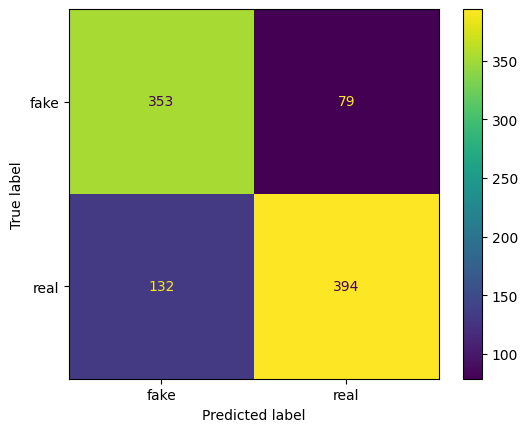

In [24]:
from sklearn.ensemble import RandomForestClassifier



rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(Xh_train, yh_train)

y_pred = rf_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()

### **grid-search**

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters: {'max_depth': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

        fake       0.74      0.82      0.78       432
        real       0.84      0.77      0.80       526

    accuracy                           0.79       958
   macro avg       0.79      0.79      0.79       958
weighted avg       0.80      0.79      0.79       958



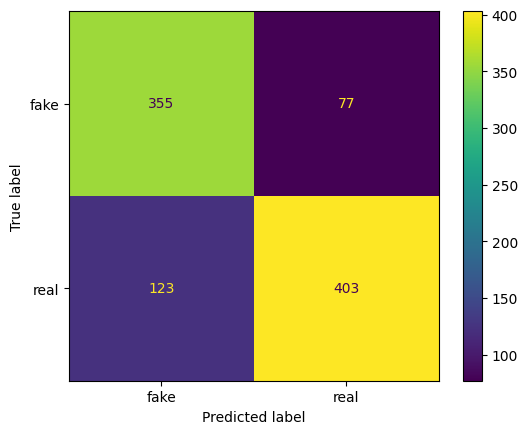

In [25]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [20, 50, 100, 150]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5, n_jobs=-1,
    verbose=2)
grid_search.fit(Xh_train, yh_train)

# model tốt nhất
best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

y_pred = best_rf.predict(Xh_test)
print(classification_report(yh_test, y_pred, target_names=['fake', 'real']))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake','real']).plot()